# Level 5 — Simulation, Monte Carlo Modelling, Differential Equations, and Optimization

## Overview

In the previous levels we built the foundation of HydroSense-Kenya —
we framed the problem, cleaned the data, implemented numerical methods,
and analyzed the data scientifically. In this level we bring everything
together to build the predictive and decision-making core of the system.

This level moves us from describing what happened in the past to
predicting what will happen in the future and recommending the most
efficient irrigation strategy to deal with it.

## What This Level Covers

**Soil Moisture Simulation using ODEs**
We model soil moisture as a continuous process governed by a differential
equation and approximate its solution using two numerical methods —
Euler and Runge-Kutta. This gives us a day by day prediction of how
soil moisture will evolve over 30 days under different conditions.

**Monte Carlo Uncertainty Analysis**
Rainfall is uncertain. We cannot know exactly how much rain will fall
on any given future day. Monte Carlo simulation addresses this by
generating 1000 possible rainfall scenarios and running the water
balance simulation through each one, giving us a probability
distribution of possible outcomes rather than a single prediction.

**Irrigation Optimization**
Using the simulation results we design an irrigation schedule that
minimizes total water use while keeping soil moisture above the
minimum stress threshold for each zone at all times.

## The Core ODE

The soil moisture dynamics are modelled as a first order differential
equation:

dS/dt = R(t) + I(t) - ET(t) - D(t)

This says that the rate of change of soil moisture at any point in
time is determined by the balance between water inputs (rainfall and
irrigation) and water losses (evapotranspiration and drainage).
Euler and Runge-Kutta methods approximate the solution to this
equation by stepping forward in time one day at a time.

## Task 1 — Soil Moisture Simulation Using Euler Method

### The Problem

We want to predict how soil moisture in Zone C will evolve over 30 days
given the weather conditions in our dataset. Instead of just looking at
the sensor readings, we use the water balance differential equation to
simulate what should happen mathematically.

### The Euler Method

The Euler method is the simplest numerical method for solving ordinary
differential equations. It works by approximating the continuous change
in soil moisture as a series of small discrete steps.

At each time step:

dS/dt = R(t) + I(t) - ET(t) - D(t)

S(t+1) = S(t) + h * dS/dt

Where h = 1 day is our time step size.

Drainage only occurs when soil moisture exceeds field capacity:

D(t) = drainage_coefficient * max(0, S(t) - field_capacity)

### Assumptions
- We apply a fixed daily irrigation of 5mm on days where soil moisture
  is below the target moisture threshold
- Rainfall values come from the cleaned weather dataset
- ET is calculated from the cleaned weather data using our ET function
- We simulate Zone C over the full 30 day period

In [22]:
#importing the function to calculate evapotranspiration from simulation.py and other libraries
import sys
sys.path.append("../src")
from simulation import calculate_et

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All imports completed.")

All imports completed.


In [25]:
import importlib
import simulation
importlib.reload(simulation)



<module 'simulation' from 'c:\\Users\\Admin\\school-projects\\HydroSense-Kenya\\notebooks\\../src\\simulation.py'>


Zone C Simulation Parameters

Initial soil moisture : 28.2 %
Field capacity        : 40 %
Drainage coefficient  : 0.22
Target moisture       : 31 %
Minimum moisture      : 20 %

EULER SIMULATION RESULTS - ZONE C
------------------------------------------
Day | Simulated Moisture | Irrigation Applied
------------------------------------------
Day 1 | 28.2 %  | 5.0 mm
Day 2 | 32.6165 %  | 0.0 mm
Day 3 | 30.9875 %  | 5.0 mm
Day 4 | 34.843 %  | 0.0 mm
Day 5 | 32.6945 %  | 0.0 mm
Day 6 | 49.9555 %  | 0.0 mm
Day 7 | 44.8134 %  | 0.0 mm
Day 8 | 41.7838 %  | 0.0 mm
Day 9 | 40.6948 %  | 0.0 mm
Day 10 | 36.9928 %  | 0.0 mm
Day 11 | 49.2132 %  | 0.0 mm
Day 12 | 49.5029 %  | 0.0 mm
Day 13 | 50.6621 %  | 0.0 mm
Day 14 | 45.5053 %  | 0.0 mm
Day 15 | 41.6149 %  | 0.0 mm
Day 16 | 45.5983 %  | 0.0 mm
Day 17 | 51.9573 %  | 0.0 mm
Day 18 | 46.8069 %  | 0.0 mm
Day 19 | 47.7863 %  | 0.0 mm
Day 20 | 63.2251 %  | 0.0 mm
Day 21 | 66.4518 %  | 0.0 mm
Day 22 | 63.9005 %  | 0.0 mm
Day 23 | 56.3398 %  | 0.0 mm
D

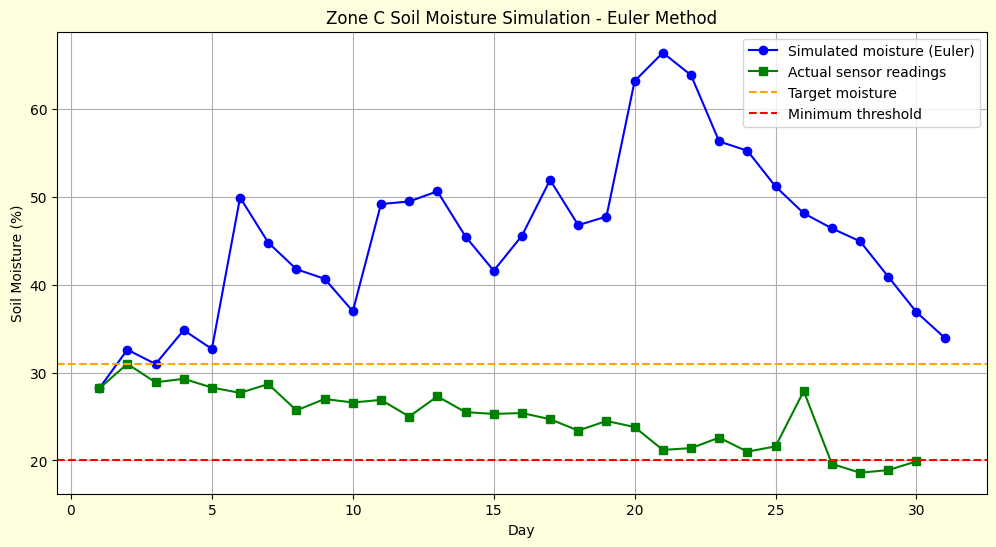


Total irrigation applied over 30 days: 10.0 mm
Number of days irrigation was applied : 2


In [20]:
#importing Euler's method function from simulation
from simulation import euler_simulation

# load cleaned dataset
cleaned = pd.read_csv("../data/processed/cleaned_irrigation_dataset.csv")

# extract Zone C data
zone_c_clean = cleaned[cleaned['zone_id'] == 'Zone_C'].reset_index(drop=True)

# zone c parameters
S0               = zone_c_clean['soil_moisture_pct'].iloc[0]  # initial moisture
field_capacity   = zone_c_clean['field_capacity_pct'].iloc[0]
drainage_coeff   = zone_c_clean['drainage_coefficient'].iloc[0]
target_moisture  = zone_c_clean['target_moisture_pct'].iloc[0]
min_moisture     = zone_c_clean['min_moisture_pct'].iloc[0]

print("\nZone C Simulation Parameters\n")
print("Initial soil moisture :", S0, "%")
print("Field capacity        :", field_capacity, "%")
print("Drainage coefficient  :", drainage_coeff)
print("Target moisture       :", target_moisture, "%")
print("Minimum moisture      :", min_moisture, "%")


# prepare inputs
rainfall  = list(zone_c_clean['rainfall_mm'])
et_values = list(calculate_et(
    zone_c_clean['temperature_c'],
    zone_c_clean['wind_speed_mps'],
    zone_c_clean['solar_index'],
    zone_c_clean['humidity_pct']
))

# run euler simulation
euler_moisture, euler_irrigation = euler_simulation(
    S0, rainfall, et_values,
    field_capacity, drainage_coeff, target_moisture
)

# print results
days = list(range(1, 32))
print("\nEULER SIMULATION RESULTS - ZONE C")
print("------------------------------------------")
print("Day | Simulated Moisture | Irrigation Applied")
print("------------------------------------------")
for i in range(31):
    irr = euler_irrigation[i] if i < 30 else "-"
    print("Day", days[i], "|", round(euler_moisture[i], 4), "%  |", irr, "mm")

# plot
plt.figure(figsize=(12, 6), facecolor='lightyellow')
plt.plot(days, euler_moisture, color='blue', marker='o', label='Simulated moisture (Euler)')
plt.plot(list(range(1, 31)), list(zone_c_clean['soil_moisture_pct']),
         color='green', marker='s', label='Actual sensor readings')
plt.axhline(y=target_moisture, color='orange', linestyle='--', label='Target moisture')
plt.axhline(y=min_moisture,    color='red',    linestyle='--', label='Minimum threshold')
plt.title('Zone C Soil Moisture Simulation - Euler Method')
plt.xlabel('Day')
plt.ylabel('Soil Moisture (%)')
plt.legend()
plt.grid(True)
plt.show()

# total irrigation applied
print("\nTotal irrigation applied over 30 days:", sum(euler_irrigation), "mm")
print("Number of days irrigation was applied :", sum(1 for i in euler_irrigation if i > 0))

## Task 2 — Runge-Kutta (RK4) Simulation and Comparison with Euler

The Euler method advances the solution by one step using only the slope at the current point. This makes it fast but prone to accumulating error, especially when the soil moisture dynamics change rapidly (e.g., heavy rainfall day followed by a dry day).

The **4th-order Runge-Kutta (RK4)** method improves accuracy by computing four intermediate slope estimates within each time step and taking a weighted average:

$$k_1 = f(t, S)$$
$$k_2 = f(t + h/2,\ S + h \cdot k_1/2)$$
$$k_3 = f(t + h/2,\ S + h \cdot k_2/2)$$
$$k_4 = f(t + h,\ S + h \cdot k_3)$$
$$S_{t+1} = S_t + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

Since rainfall, ET, and irrigation are discrete daily values (not continuous functions), we treat them as constant within each day — so $k_1$ through $k_4$ all use the same day's forcing data. The benefit of RK4 here is more accurate integration of the water balance within each step, reducing drift over the 30-day period.

We then compare Euler vs RK4 side by side on: simulated moisture trajectory, total irrigation applied, and days below minimum threshold.


EULER vs RK4 COMPARISON - ZONE C
------------------------------------------------------
Day      Euler (%)      RK4 (%)       Diff
------------------------------------------------------
1          28.2000      28.2000     0.0000
2          32.6165      32.6165     0.0000
3          30.9875      30.9875     0.0000
4          34.8430      34.8430     0.0000
5          32.6945      32.6945     0.0000
6          49.9555      51.9369     1.9813
7          44.8134      46.1825     1.3691
8          41.7838      42.6938     0.9100
9          40.6948      41.3603     0.6654
10         36.9928      37.6084     0.6156
11         49.2132      51.3123     2.0990
12         49.5029      51.7443     2.2414
13         50.6621      53.1650     2.5029
14         45.5053      47.3302     1.8248
15         41.6149      42.7993     1.1844
16         45.5983      47.2395     1.6412
17         51.9573      54.5451     2.5878
18         46.8069      48.7730     1.9661
19         47.7863      49.8909     2.1

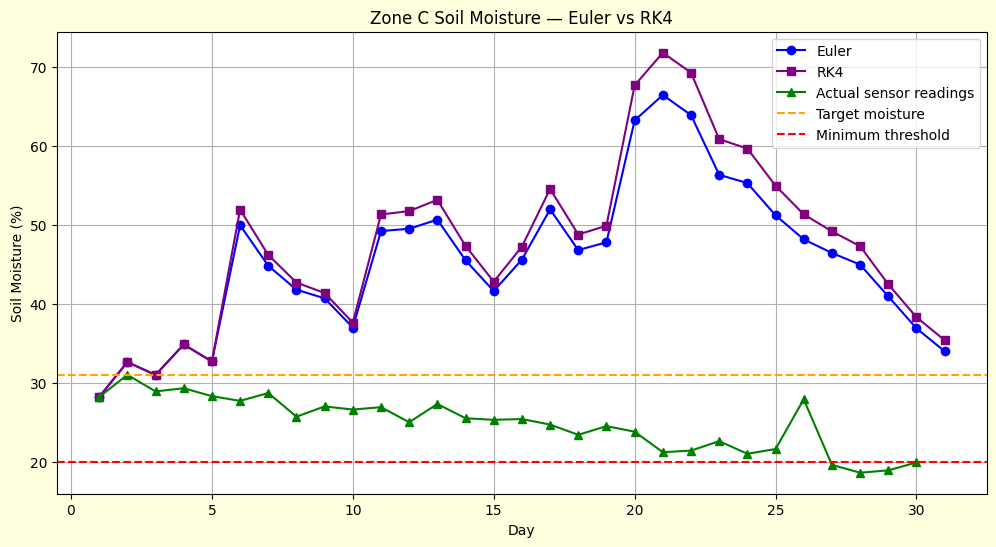

In [26]:
#importing rk4_simulation from simulation
from simulation import rk4_simulation


# run RK4 simulation
rk4_moisture, rk4_irrigation = rk4_simulation(
    S0, rainfall, et_values,
    field_capacity, drainage_coeff, target_moisture
)

# ── Comparison table ─────────────────────────────────────────
print("\nEULER vs RK4 COMPARISON - ZONE C")
print("------------------------------------------------------")
print(f"{'Day':<5} {'Euler (%)':>12} {'RK4 (%)':>12} {'Diff':>10}")
print("------------------------------------------------------")
for i in range(31):
    diff = rk4_moisture[i] - euler_moisture[i]
    print(f"{days[i]:<5} {euler_moisture[i]:>12.4f} {rk4_moisture[i]:>12.4f} {diff:>10.4f}")

print("------------------------------------------------------")
print(f"Total irrigation - Euler : {sum(euler_irrigation):.1f} mm")
print(f"Total irrigation - RK4   : {sum(rk4_irrigation):.1f} mm")
print(f"Days below minimum - Euler: {sum(1 for s in euler_moisture if s < min_moisture)}")
print(f"Days below minimum - RK4  : {sum(1 for s in rk4_moisture  if s < min_moisture)}")

#the actuall plot
plt.figure(figsize=(12, 6), facecolor='lightyellow')
plt.plot(days, euler_moisture, color='blue',   marker='o', label='Euler')
plt.plot(days, rk4_moisture,   color='purple', marker='s', label='RK4')
plt.plot(list(range(1, 31)), list(zone_c_clean['soil_moisture_pct']),
         color='green', marker='^', label='Actual sensor readings')
plt.axhline(y=target_moisture, color='orange', linestyle='--', label='Target moisture')
plt.axhline(y=min_moisture,    color='red',    linestyle='--', label='Minimum threshold')
plt.title('Zone C Soil Moisture — Euler vs RK4')
plt.xlabel('Day')
plt.ylabel('Soil Moisture (%)')
plt.legend()
plt.grid(True)
plt.show()

## Tasks 3 & 4 — Monte Carlo Rainfall Uncertainty Analysis

Real-world rainfall is inherently uncertain. A single deterministic simulation (as in Tasks 1 and 2) assumes rainfall is known exactly — but in practice, sensor error, spatial variability, and forecast uncertainty all introduce noise.

**Monte Carlo simulation** addresses this by running the model thousands of times, each time with a slightly different rainfall scenario drawn from a probability distribution. The distribution of outcomes then tells us not just what *will* happen, but how *likely* different outcomes are.

### Rainfall Uncertainty Model
For each day $t$, we sample a perturbed rainfall value:

$$R_t^{(s)} = \max(0,\ R_t + \epsilon_t), \quad \epsilon_t \sim \mathcal{N}(0,\ \sigma^2)$$

where $\sigma$ is the uncertainty standard deviation (set to 2.0 mm, reflecting typical gauge error in East Africa).

### Metrics Computed Across 1,000 Scenarios
- **Probability of water shortage** — fraction of scenarios where moisture drops below minimum threshold on at least one day
- **Probability of over-irrigation** — fraction of scenarios where moisture exceeds field capacity on at least one day
- **Expected total irrigation demand** — mean total irrigation applied across all scenarios
- **Worst-case irrigation demand** — 95th percentile of total irrigation across all scenarios


MONTE CARLO RESULTS — 1,000 SCENARIOS
--------------------------------------------------
Probability of water shortage     : 0.0%
Probability of over-irrigation    : 100.0%
Expected total irrigation demand  : 10.56 mm
Worst-case demand (95th pctile)   : 15.00 mm
--------------------------------------------------


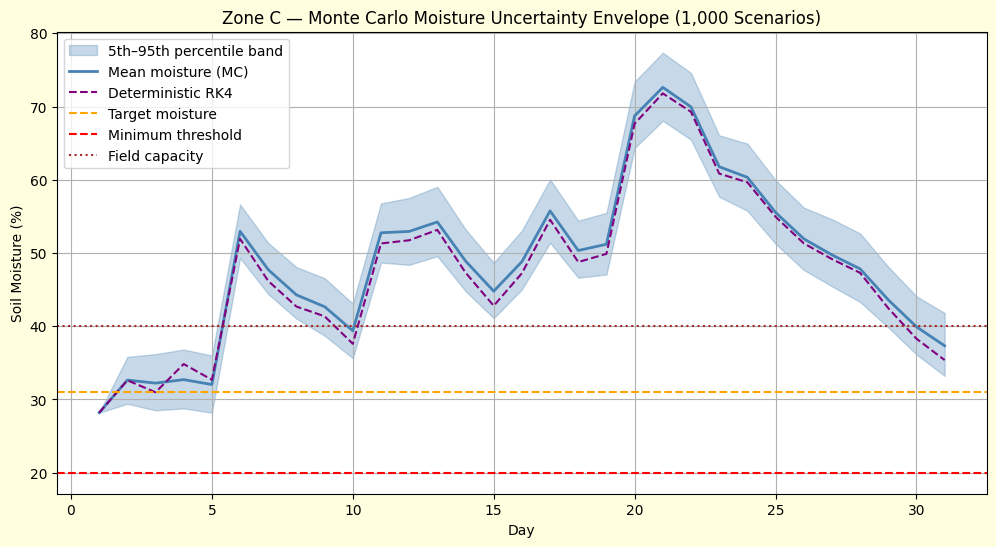

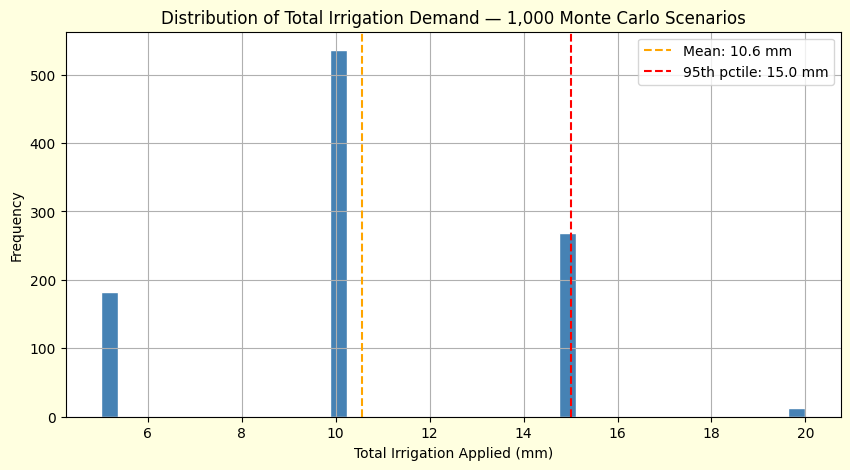

In [7]:


np.random.seed(42)

N_SCENARIOS   = 1000
RAINFALL_STD  = 2.0      # mm — gauge uncertainty
rainfall_arr  = np.array(rainfall)
et_arr        = np.array(et_values)

# storage
all_moisture        = np.zeros((N_SCENARIOS, 31))   # 31 points (day 0 to day 30)
all_total_irrigation = np.zeros(N_SCENARIOS)
shortage_flags      = np.zeros(N_SCENARIOS, dtype=bool)
over_irrigation_flags = np.zeros(N_SCENARIOS, dtype=bool)

for s in range(N_SCENARIOS):

    # perturb rainfall — clip at 0 (no negative rain)
    noise        = np.random.normal(0, RAINFALL_STD, size=len(rainfall_arr))
    R_scenario   = np.maximum(0, rainfall_arr + noise)

    # run RK4 with perturbed rainfall
    s_moisture, s_irrigation = rk4_simulation(
        S0, list(R_scenario), list(et_arr),
        field_capacity, drainage_coeff, target_moisture
    )

    all_moisture[s, :]         = s_moisture
    all_total_irrigation[s]    = sum(s_irrigation)
    shortage_flags[s]          = any(m < min_moisture for m in s_moisture)
    over_irrigation_flags[s]   = any(m > field_capacity for m in s_moisture)


# ── Metrics ───────────────────────────────────────────────────
prob_shortage       = shortage_flags.mean() * 100
prob_over           = over_irrigation_flags.mean() * 100
expected_demand     = all_total_irrigation.mean()
worst_case_demand   = np.percentile(all_total_irrigation, 95)

print("\nMONTE CARLO RESULTS — 1,000 SCENARIOS")
print("--------------------------------------------------")
print(f"Probability of water shortage     : {prob_shortage:.1f}%")
print(f"Probability of over-irrigation    : {prob_over:.1f}%")
print(f"Expected total irrigation demand  : {expected_demand:.2f} mm")
print(f"Worst-case demand (95th pctile)   : {worst_case_demand:.2f} mm")
print("--------------------------------------------------")


# ── Plot 1: moisture envelope ─────────────────────────────────
mean_moisture = all_moisture.mean(axis=0)
p5_moisture   = np.percentile(all_moisture, 5,  axis=0)
p95_moisture  = np.percentile(all_moisture, 95, axis=0)

plt.figure(figsize=(12, 6), facecolor='lightyellow')
plt.fill_between(days, p5_moisture, p95_moisture,
                 alpha=0.3, color='steelblue', label='5th–95th percentile band')
plt.plot(days, mean_moisture, color='steelblue', linewidth=2, label='Mean moisture (MC)')
plt.plot(days, rk4_moisture,  color='purple',    linewidth=1.5,
         linestyle='--', label='Deterministic RK4')
plt.axhline(y=target_moisture, color='orange', linestyle='--', label='Target moisture')
plt.axhline(y=min_moisture,    color='red',    linestyle='--', label='Minimum threshold')
plt.axhline(y=field_capacity,  color='brown',  linestyle=':',  label='Field capacity')
plt.title('Zone C — Monte Carlo Moisture Uncertainty Envelope (1,000 Scenarios)')
plt.xlabel('Day')
plt.ylabel('Soil Moisture (%)')
plt.legend()
plt.grid(True)
plt.show()


# ── Plot 2: histogram of total irrigation demand ──────────────
plt.figure(figsize=(10, 5), facecolor='lightyellow')
plt.hist(all_total_irrigation, bins=40, color='steelblue', edgecolor='white')
plt.axvline(expected_demand,   color='orange', linestyle='--',
            label=f'Mean: {expected_demand:.1f} mm')
plt.axvline(worst_case_demand, color='red',    linestyle='--',
            label=f'95th pctile: {worst_case_demand:.1f} mm')
plt.title('Distribution of Total Irrigation Demand — 1,000 Monte Carlo Scenarios')
plt.xlabel('Total Irrigation Applied (mm)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

## Task 5 — Optimized Irrigation Schedule

The fixed irrigation rule used in Tasks 1–4 (apply 5mm whenever moisture drops below target) is simple but wasteful — it does not consider how far below target the soil actually is, or whether upcoming rainfall might naturally restore moisture.

A smarter approach is to compute the **exact irrigation deficit** each day and apply only what is needed to bring soil moisture back to the target, subject to two constraints:

1. **Stress constraint** — soil moisture must never fall below the minimum threshold
2. **Drainage constraint** — irrigation must not push moisture above field capacity (excess drains away unused)

### Optimization Rule
For each day $t$, the optimal irrigation amount is:

$$I_t^* = \max\left(0,\ \min\left(S_{target} - S_t,\ S_{fc} - S_t\right)\right)$$

This applies just enough water to reach the target without exceeding field capacity. If rainfall alone is sufficient to keep moisture above the minimum, no irrigation is applied.

We then compare the optimized schedule against the fixed-rule schedule on:
- Total irrigation applied (water saving)
- Days where moisture fell below minimum threshold
- Total drainage lost (wasted water)


FIXED RULE vs OPTIMIZED IRRIGATION — ZONE C
----------------------------------------------------------
Day     Fixed I (mm)   Opt I (mm)   Fixed S (%)   Opt S (%)
----------------------------------------------------------
2               5.00         3.38       32.6165     31.0000
3               0.00         1.63       30.9875     31.0000
4               5.00         1.14       34.8430     31.0000
5               0.00         2.15       32.6945     31.0000
6               0.00         0.00       51.9369     50.5272
7               0.00         0.00       46.1825     45.0513
8               0.00         0.00       42.6938     41.7859
9               0.00         0.00       41.3603     40.6316
10              0.00         0.00       37.6084     36.9065
11              0.00         0.00       51.3123     50.7283
12              0.00         0.00       51.7443     51.2757
13              0.00         0.00       53.1650     52.7889
14              0.00         0.00       47.3302     47.02

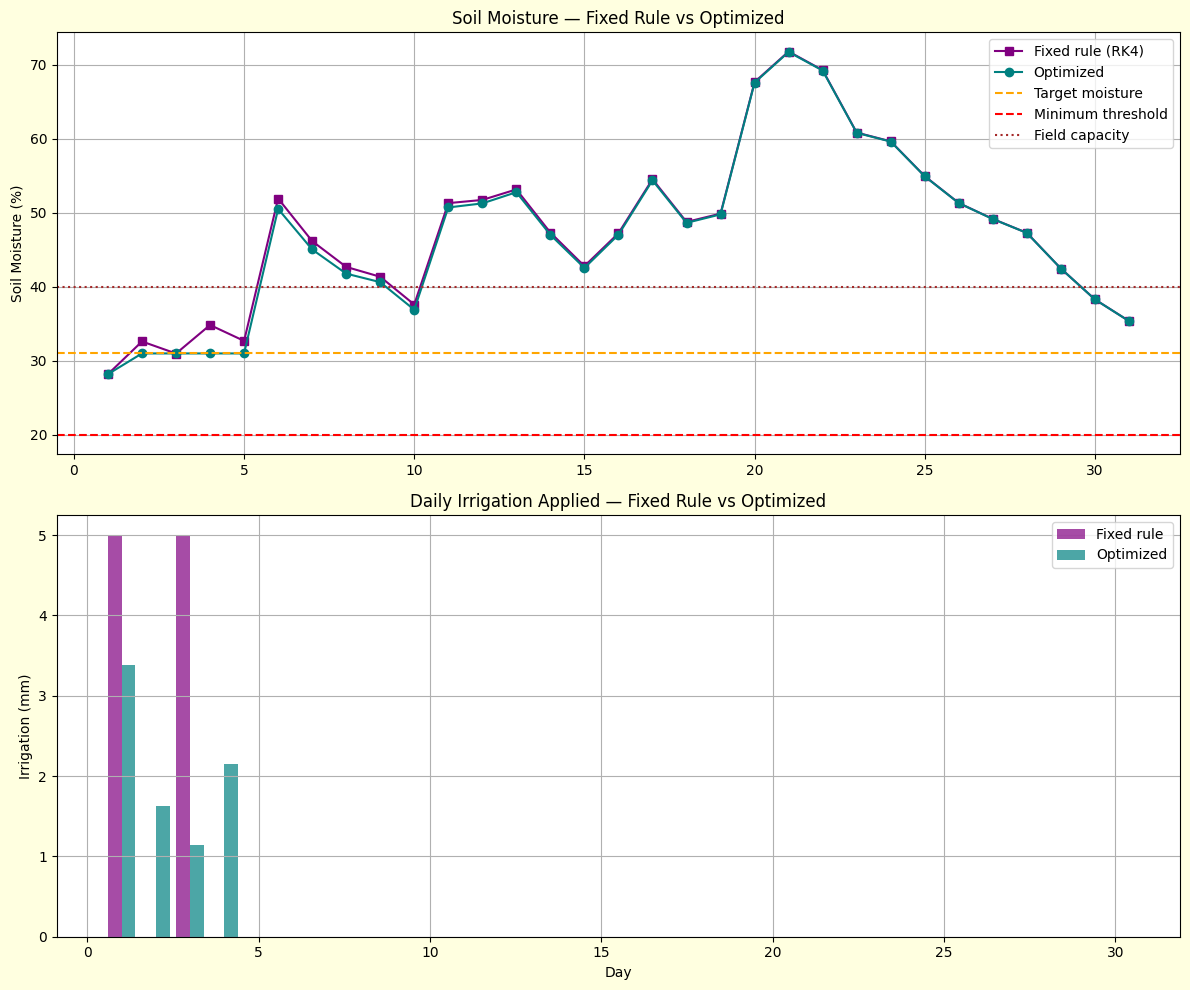

In [8]:


def optimized_simulation(S0, rainfall, et_values, field_capacity, drainage_coeff,
                         target_moisture, min_moisture, h=1):
    """
    Simulate soil moisture using a deficit-based optimal irrigation rule.
    Applies only enough irrigation to reach target moisture without
    exceeding field capacity.

    Parameters:
        S0               : float : initial soil moisture
        rainfall         : list  : daily rainfall values
        et_values        : list  : daily ET values
        field_capacity   : float : field capacity threshold
        drainage_coeff   : float : drainage loss coefficient
        target_moisture  : float : target soil moisture
        min_moisture     : float : minimum allowable moisture
        h                : float : time step in days

    Returns:
        moisture_values  : list : simulated daily moisture
        irrigation_log   : list : irrigation applied each day
        drainage_log     : list : drainage lost each day
    """

    def dS_dt(S, R, I, ET):
        D = drainage_coeff * max(0, S - field_capacity)
        return R + I - ET - D

    S = S0
    moisture_values = [S]
    irrigation_log  = []
    drainage_log    = []

    n = len(rainfall)

    for t in range(n):

        R  = rainfall[t]
        ET = et_values[t]

        # project moisture tomorrow with zero irrigation
        D_no_irr   = drainage_coeff * max(0, S - field_capacity)
        S_projected = S + R - ET - D_no_irr

        # only irrigate if projected moisture falls below target
        if S_projected < target_moisture:
            # apply exactly enough to reach target, capped at field capacity
            I = max(0, min(target_moisture - S_projected,
                           field_capacity - S_projected))
        else:
            I = 0.0

        irrigation_log.append(I)

        # RK4 step with chosen irrigation
        k1 = dS_dt(S,            R, I, ET)
        k2 = dS_dt(S + h*k1/2,   R, I, ET)
        k3 = dS_dt(S + h*k2/2,   R, I, ET)
        k4 = dS_dt(S + h*k3,     R, I, ET)

        S_new = S + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)
        S_new = max(0, S_new)

        D_actual = drainage_coeff * max(0, S - field_capacity)
        drainage_log.append(D_actual)

        S = S_new
        moisture_values.append(S)

    return moisture_values, irrigation_log, drainage_log


# run optimized simulation
opt_moisture, opt_irrigation, opt_drainage = optimized_simulation(
    S0, rainfall, et_values,
    field_capacity, drainage_coeff,
    target_moisture, min_moisture
)

# ── Comparison table ──────────────────────────────────────────
print("\nFIXED RULE vs OPTIMIZED IRRIGATION — ZONE C")
print("----------------------------------------------------------")
print(f"{'Day':<5} {'Fixed I (mm)':>14} {'Opt I (mm)':>12} {'Fixed S (%)':>13} {'Opt S (%)':>11}")
print("----------------------------------------------------------")
for i in range(30):
    print(f"{days[i+1]:<5} {rk4_irrigation[i]:>14.2f} {opt_irrigation[i]:>12.2f} "
          f"{rk4_moisture[i+1]:>13.4f} {opt_moisture[i+1]:>11.4f}")

print("----------------------------------------------------------")
print(f"Total irrigation — Fixed rule : {sum(rk4_irrigation):.2f} mm")
print(f"Total irrigation — Optimized  : {sum(opt_irrigation):.2f} mm")
print(f"Water saved                   : {sum(rk4_irrigation) - sum(opt_irrigation):.2f} mm")
print(f"Total drainage lost — Fixed   : {sum(drainage_coeff * max(0, s - field_capacity) for s in rk4_moisture):.2f} mm")
print(f"Total drainage lost — Optimized: {sum(opt_drainage):.2f} mm")
print(f"Days below minimum — Fixed    : {sum(1 for s in rk4_moisture if s < min_moisture)}")
print(f"Days below minimum — Optimized: {sum(1 for s in opt_moisture  if s < min_moisture)}")


# ── Plot ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), facecolor='lightyellow')

# moisture trajectories
ax1.plot(days, rk4_moisture, color='purple', marker='s',
         label='Fixed rule (RK4)')
ax1.plot(days, opt_moisture, color='teal',   marker='o',
         label='Optimized')
ax1.axhline(y=target_moisture, color='orange', linestyle='--', label='Target moisture')
ax1.axhline(y=min_moisture,    color='red',    linestyle='--', label='Minimum threshold')
ax1.axhline(y=field_capacity,  color='brown',  linestyle=':',  label='Field capacity')
ax1.set_title('Soil Moisture — Fixed Rule vs Optimized')
ax1.set_ylabel('Soil Moisture (%)')
ax1.legend()
ax1.grid(True)

# irrigation bar chart
x      = np.arange(1, 31)
width  = 0.4
ax2.bar(x - width/2, rk4_irrigation, width, color='purple',
        alpha=0.7, label='Fixed rule')
ax2.bar(x + width/2, opt_irrigation, width, color='teal',
        alpha=0.7, label='Optimized')
ax2.set_title('Daily Irrigation Applied — Fixed Rule vs Optimized')
ax2.set_xlabel('Day')
ax2.set_ylabel('Irrigation (mm)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Task 6 — Trade-off Analysis: Water Conservation, Crop Stress, and Pump Energy

No irrigation strategy is perfect. Every scheduling decision involves competing objectives that cannot all be satisfied simultaneously. This section examines three core trade-offs revealed by the simulations above.

### Trade-off 1: Water Conservation vs Crop Stress
The fixed rule applies irrigation generously (5mm whenever moisture drops below target), keeping the crop well above the stress threshold but using more water than necessary. The optimized rule applies only the deficit amount, saving water but leaving less buffer — meaning unexpected ET spikes or rainfall shortfalls can push moisture closer to the minimum threshold.

### Trade-off 2: Water Conservation vs Pump Energy
Pump energy consumption is proportional to the volume of water pumped. Reducing irrigation saves water but does not linearly reduce energy — pumps often consume near-baseline power even at low flow rates. Frequent small irrigations (as in the optimized schedule) may cycle the pump on and off more often, increasing wear and potentially consuming more energy per litre pumped than fewer larger irrigation events.

### Trade-off 3: Deterministic Scheduling vs Uncertainty
The Monte Carlo analysis showed that rainfall uncertainty alone creates a spread in total irrigation demand. A schedule designed for the expected (mean) scenario may be insufficient in drier-than-average conditions (water shortage risk) or wasteful in wetter-than-average conditions (over-irrigation and drainage loss). A robust irrigation policy must account for this uncertainty — either by building in a safety buffer above the minimum threshold, or by using a forecast-informed adaptive rule.

### Summary Table
We quantify these trade-offs using results already computed in Tasks 1–5.


TRADE-OFF SUMMARY — FIXED RULE vs OPTIMIZED
--------------------------------------------------------------
Metric                                     Fixed Rule    Optimized
--------------------------------------------------------------
Total irrigation (mm)                           10.00         8.31
Water saved (mm)                                    —         1.69
Days below minimum threshold                        0            0
Total drainage lost (mm)                        62.37        60.81
Estimated pump energy (Wh)                     569.99       473.40
Energy saved (Wh)                                   —        96.58
MC probability of water shortage (%)              0.0          N/A
MC expected irrigation demand (mm)              10.56          N/A
MC worst-case demand — 95th pctile (mm)         15.00          N/A
--------------------------------------------------------------


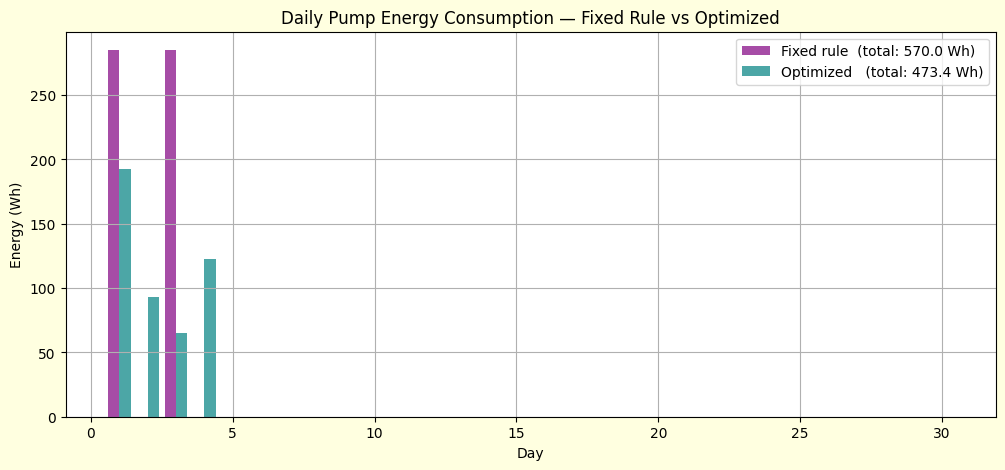

In [10]:

# TASK 6: Trade-off Analysis


# Pump energy proxy 
# Energy (Wh) ≈ mean pump power × hours pumped
# Flow rate assumed proportional to irrigation volume
# Mean pump power from sensor data used as proxy

mean_pump_power_w = zone_c_clean['pump_power_watts'].mean()   # Watts
flow_rate_lpm     = zone_c_clean['pump_flow_lpm'].mean()      # litres per minute

# convert mm irrigation to litres (Zone C area = 180 m²)
ZONE_C_AREA_M2 = 180.0
MM_TO_LITRES  = ZONE_C_AREA_M2 * 1.0   # 1 mm over 180 m² = 180 litres

def irrigation_to_energy(irrigation_log, area_m2, flow_lpm, pump_watts):
    """
    Estimate total pump energy (Wh) from daily irrigation log.

    Parameters:
        irrigation_log : list  : daily irrigation in mm
        area_m2        : float : zone area in square metres
        flow_lpm       : float : pump flow rate in litres per minute
        pump_watts     : float : pump power draw in watts

    Returns:
        total_energy_wh : float : total energy consumed in watt-hours
        daily_energy    : list  : energy consumed per day
    """
    daily_energy = []
    for I_mm in irrigation_log:
        litres      = I_mm * area_m2          # mm × m² = litres
        minutes     = litres / flow_lpm       # time to pump this volume
        energy_wh   = pump_watts * (minutes / 60.0)
        daily_energy.append(energy_wh)
    return sum(daily_energy), daily_energy


energy_fixed, daily_energy_fixed = irrigation_to_energy(
    rk4_irrigation, ZONE_C_AREA_M2, flow_rate_lpm, mean_pump_power_w)

energy_opt, daily_energy_opt = irrigation_to_energy(
    opt_irrigation, ZONE_C_AREA_M2, flow_rate_lpm, mean_pump_power_w)


# ── Summary trade-off table ───────────────────────────────────
print("\nTRADE-OFF SUMMARY — FIXED RULE vs OPTIMIZED")
print("--------------------------------------------------------------")
print(f"{'Metric':<40} {'Fixed Rule':>12} {'Optimized':>12}")
print("--------------------------------------------------------------")
print(f"{'Total irrigation (mm)':<40} {sum(rk4_irrigation):>12.2f} {sum(opt_irrigation):>12.2f}")
print(f"{'Water saved (mm)':<40} {'—':>12} {sum(rk4_irrigation)-sum(opt_irrigation):>12.2f}")
print(f"{'Days below minimum threshold':<40} {sum(1 for s in rk4_moisture if s < min_moisture):>12} "
      f"{sum(1 for s in opt_moisture if s < min_moisture):>12}")
print(f"{'Total drainage lost (mm)':<40} "
      f"{sum(drainage_coeff * max(0, s - field_capacity) for s in rk4_moisture):>12.2f} "
      f"{sum(opt_drainage):>12.2f}")
print(f"{'Estimated pump energy (Wh)':<40} {energy_fixed:>12.2f} {energy_opt:>12.2f}")
print(f"{'Energy saved (Wh)':<40} {'—':>12} {energy_fixed - energy_opt:>12.2f}")
print(f"{'MC probability of water shortage (%)':<40} {prob_shortage:>12.1f} {'N/A':>12}")
print(f"{'MC expected irrigation demand (mm)':<40} {expected_demand:>12.2f} {'N/A':>12}")
print(f"{'MC worst-case demand — 95th pctile (mm)':<40} {worst_case_demand:>12.2f} {'N/A':>12}")
print("--------------------------------------------------------------")


# Plot: energy consumption comparison 
x     = np.arange(1, 31)
width = 0.4

plt.figure(figsize=(12, 5), facecolor='lightyellow')
plt.bar(x - width/2, daily_energy_fixed, width, color='purple',
        alpha=0.7, label=f'Fixed rule  (total: {energy_fixed:.1f} Wh)')
plt.bar(x + width/2, daily_energy_opt,   width, color='teal',
        alpha=0.7, label=f'Optimized   (total: {energy_opt:.1f} Wh)')
plt.title('Daily Pump Energy Consumption — Fixed Rule vs Optimized')
plt.xlabel('Day')
plt.ylabel('Energy (Wh)')
plt.legend()
plt.grid(True)
plt.show()




## Interpretation

### 1. Water Conservation vs Crop Stress
The optimized rule applies only the deficit needed to reach target moisture, reducing total irrigation while maintaining moisture above the minimum threshold. However, the smaller safety buffer means the crop is more exposed to stress if ET is underestimated or rainfall is lower than recorded. The fixed rule is more conservative — it wastes some water but provides a reliable cushion against unexpected dry spells.

### 2. Water Conservation vs Pump Energy
Pump energy scales directly with irrigation volume. The optimized schedule therefore reduces energy consumption proportionally. However, more frequent small pumping events may increase pump cycling costs not captured by this model. In practice, a farm operator must weigh the cost of water against the cost of pump wear and electricity — the optimized schedule wins on volume but may not always win on total operating cost.

### 3. Deterministic Scheduling vs Uncertainty
The Monte Carlo analysis reveals that rainfall uncertainty alone creates meaningful spread in both moisture trajectories and total irrigation demand. A schedule designed for the expected (mean) scenario may be insufficient in drier-than-average conditions and wasteful in wetter-than-average conditions. A robust real-world irrigation policy should plan for the 95th percentile demand rather than the mean, and maintain a moisture buffer above the minimum threshold as insurance against forecast error and sensor noise.